In [21]:
library(ggplot2)
library(readr)
library(corrplot)
library(FactoMineR)

In [22]:
europe <- read_table("C:\\Users\\Julien ANTOGNELLI\\Documents\\ESGI\\Maths\\MathsForR\\data\\Donnees Europe.dat", 
    skip = 1,
    col_names =c (
        "pays", "benev", "chom", "depsoc", "devel", "heur", "pib",
        "satfam", "satlogt", "satnvie", "spauvr", "ssabri", "vief", "vieh")
)


── Column specification ────────────────────────────────────────────────────────
cols(
  pays = col_character(),
  benev = col_double(),
  chom = col_double(),
  depsoc = col_double(),
  devel = col_double(),
  heur = col_double(),
  pib = col_double(),
  satfam = col_double(),
  satlogt = col_double(),
  satnvie = col_double(),
  spauvr = col_double(),
  ssabri = col_double(),
  vief = col_double(),
  vieh = col_double()
)



# Introduction au jeu de données

In [23]:
head(europe)

pays,benev,chom,depsoc,devel,heur,pib,satfam,satlogt,satnvie,spauvr,ssabri,vief,vieh
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
at,60,4.7,29.1,0.944,20,128.8,8.2,39,32,900,3,82,77
be,37,8.1,29.3,0.945,40,112.3,7.9,55,35,822,5,82,77
cy,23,4.6,17.8,0.903,24,93.2,7.9,49,24,658,4,82,77
cz,33,7.7,19.6,0.885,16,79.4,7.5,37,14,212,6,79,73
de,52,9.1,29.5,0.932,24,113.6,8.1,52,31,856,2,82,76
dk,49,4.9,30.7,0.943,49,126.7,8.7,55,55,1106,1,80,76


## Graphes de couples de variables

### Couple `chom`et `depsoc`

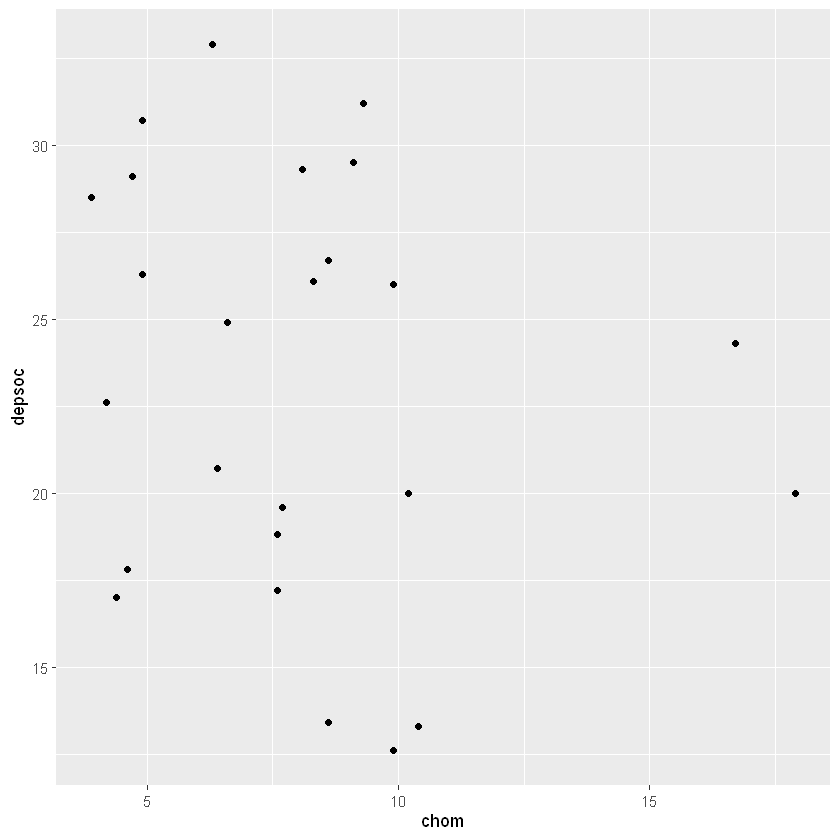

In [24]:
ggplot(europe, aes(x = chom, y = depsoc)) +
  geom_point() +
  labs(x = "chom",
       y = "depsoc")

### Couple `PIB`et `devel`

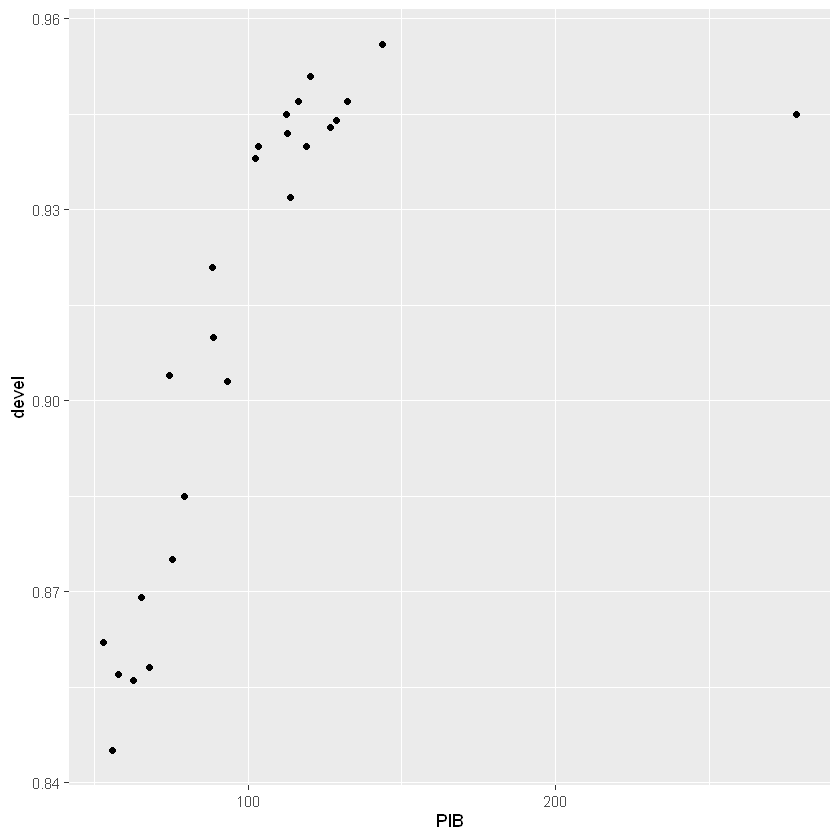

In [25]:
ggplot(europe, aes(x = pib, y = devel)) +
  geom_point() +
  labs(x = "PIB",
       y = "devel")

### Couple `benev`et `pvapr`
**TODO** /!\ `pvapr`n'existe pas dans le fichier

## Matrice des corrélations des variables

In [26]:
Europe_num <- europe[, -1]   # enlève la colonne pays

In [27]:
cor_mat <- round(cor(Europe_num, method = "pearson"), 2)
cor_mat
write.csv(cor_mat, file = "./graphs_&_tables/corr_matrix.csv", row.names = TRUE)

,benev,chom,depsoc,devel,heur,pib,satfam,satlogt,satnvie,spauvr,ssabri,vief,vieh
benev,1.00,-0.41,0.58,0.62,0.52,0.56,0.39,0.52,0.58,0.67,-0.56,0.40,0.43
chom,-0.41,1.00,-0.19,-0.56,-0.57,-0.55,-0.40,-0.54,-0.61,-0.63,0.40,-0.35,-0.46
depsoc,0.58,-0.19,1.00,0.70,0.49,0.36,0.47,0.39,0.49,0.61,-0.50,0.59,0.66
devel,0.62,-0.56,0.70,1.00,0.76,0.69,0.67,0.61,0.74,0.88,-0.55,0.86,0.84
heur,0.52,-0.57,0.49,0.76,1.00,0.64,0.61,0.80,0.88,0.81,-0.52,0.51,0.63
pib,0.56,-0.55,0.36,0.69,0.64,1.00,0.54,0.70,0.80,0.87,-0.48,0.52,0.52
satfam,0.39,-0.40,0.47,0.67,0.61,0.54,1.00,0.68,0.77,0.72,-0.64,0.60,0.77
satlogt,0.52,-0.54,0.39,0.61,0.80,0.70,0.68,1.00,0.83,0.79,-0.59,0.49,0.65
satnvie,0.58,-0.61,0.49,0.74,0.88,0.80,0.77,0.83,1.00,0.89,-0.63,0.52,0.68
spauvr,0.67,-0.63,0.61,0.88,0.81,0.87,0.72,0.79,0.89,1.00,-0.54,0.70,0.76


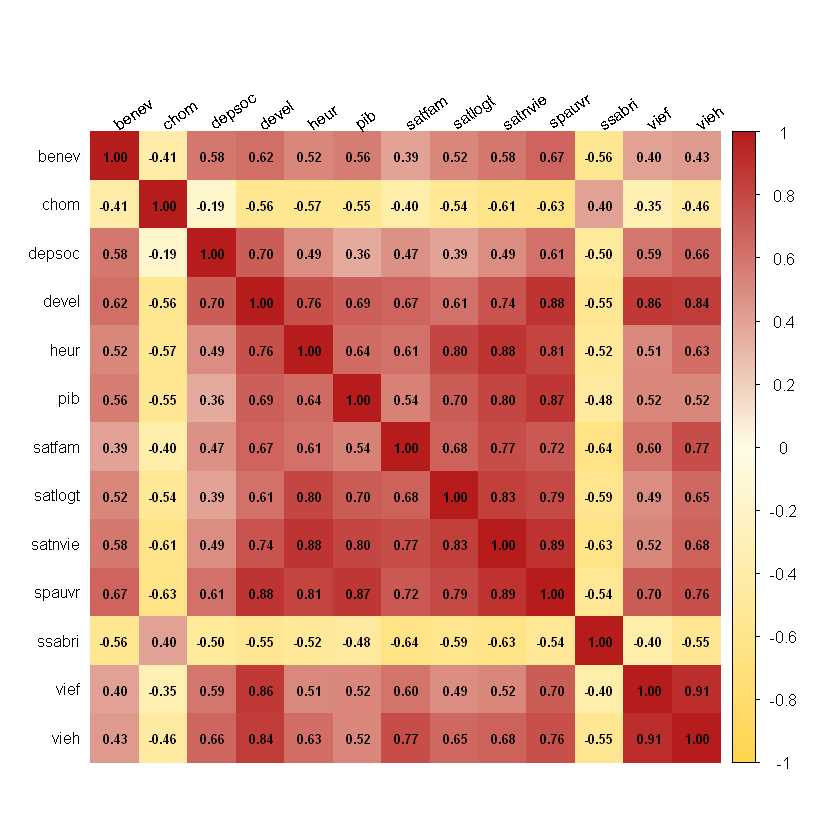

In [28]:
corrplot(cor_mat,
         method = "color",
         type = "full",
         diag = TRUE,
         col = colorRampPalette(c("#FFD54F", "#FFFDE7", "#B71C1C"))(200),
         tl.col = "black",
         tl.cex = 0.8,
         tl.srt = 35,
         addCoef.col = "black",
         number.cex = 0.65,
         mar = c(1, 1, 2, 1))

**Interprétation**

Le couple de variables le plus corrélé est (vief, vieh) avec un coefficient de corrélation de 0,91, ce qui traduit une très forte liaison linéaire positive.

Le couple le moins corrélé est (chom, depsoc) avec -0,19, la liaison linéaire étant très faible.

Le couple de variables le plus opposé est (satfam, ssabri) avec -0,64, ce qui indique une corrélation négative marquée.

**TODO** -- Pour chacun des couples (chom, depsoc), (pib, devel) et (benev, pvap), commentez la répartition
des valeurs, identi ez les éventuels individus "anormaux" et expliquez le lien avec les corrélations
mesurées.

# Première ACP

### Pré-traitement du df avant manipulations

In [40]:
europe <- as.data.frame(europe)

# Mettre la 1re colonne (pays) en noms de lignes
rownames(europe) <- europe[, 1]

# Supprimer la 1re colonne du tableau de données
europe_num <- europe[, -1]

## Centrer et réduire les données

In [39]:
res.pca <- PCA(europe_num, scale.unit = TRUE, ncp = 4, graph = FALSE)

## Variances des composantes principales

In [60]:
variances_cp <- data.frame(
  Axe = paste0("Dim.", 1:4),
  Variance = round(res.pca$eig[1:4, 1], 4)
)

variances_cp
write.csv(variances_cp, file = "./graphs_&_tables/variances_cp.csv", row.names = FALSE)

,Axe,Variance
,<chr>,<dbl>
comp 1,Dim.1,8.3909
comp 2,Dim.2,1.2172
comp 3,Dim.3,0.8408
comp 4,Dim.4,0.7304


## Tableau de corrélation des variables

In [55]:
corr_variables <- round(res.pca$var$cor[, 1:4], 4)
corr_variables
write.csv(corr_variables, file = "./graphs_&_tables/corr_variables.csv", row.names = TRUE)

,Dim.1,Dim.2,Dim.3,Dim.4
benev,0.6880,-0.0388,-0.5956,0.2495
chom,-0.6360,0.4325,-0.1705,-0.2454
depsoc,0.6691,0.5168,-0.3532,0.0764
devel,0.9143,0.2305,0.0658,0.2109
heur,0.8467,-0.2222,0.0541,-0.0001
pib,0.8001,-0.3045,0.0237,0.2058
satfam,0.8005,0.0800,0.1641,-0.4432
satlogt,0.8304,-0.3014,0.0592,-0.1975
satnvie,0.9122,-0.2695,0.0167,-0.1137
spauvr,0.9556,-0.0845,0.0379,0.1693


## Coordonées des individus sur les axes

In [57]:
coord_individus <- round(res.pca$ind$coord[, 1:4], 4)
coord_individus
write.csv(coord_individus, file = "./graphs_&_tables/coord_individus.csv", row.names = TRUE)

,Dim.1,Dim.2,Dim.3,Dim.4
at,2.2026,0.5746,-1.1379,0.7055
be,2.0526,0.4308,-0.0443,0.1003
cy,0.2642,-0.3718,1.2112,-0.4768
cz,-1.9987,-0.3383,-0.4339,-0.1758
de,1.8218,0.7689,-1.1992,-0.2011
dk,3.8231,-0.9105,-0.8755,-0.7656
ee,-4.1636,-1.1473,-0.7150,0.8575
es,0.3029,1.2867,1.5153,-0.6805
fi,1.7138,0.7827,-0.8622,-0.0062
fr,0.5918,1.8470,0.5494,2.0517


## Contribution des individus aux axes 

In [59]:
contrib_individus <- round(res.pca$ind$contrib[, 1:4], 2)
contrib_individus
write.csv(contrib_individus, file = "./graphs_&_tables/contrib_individus.csv", row.names = TRUE)

,Dim.1,Dim.2,Dim.3,Dim.4
at,2.31,1.08,6.16,2.73
be,2.01,0.61,0.01,0.06
cy,0.03,0.45,6.98,1.24
cz,1.90,0.38,0.90,0.17
de,1.58,1.94,6.84,0.22
dk,6.97,2.72,3.65,3.21
ee,8.26,4.33,2.43,4.03
es,0.04,5.44,10.92,2.54
fi,1.40,2.01,3.54,0.00
fr,0.17,11.21,1.44,23.05


Faites une représentation graphique des valeurs propres. Combien de composantes principales
faut-il retenir? Quel est le pourcentage d'inertie totale expliquée par le sous-espace principal
correspondant?

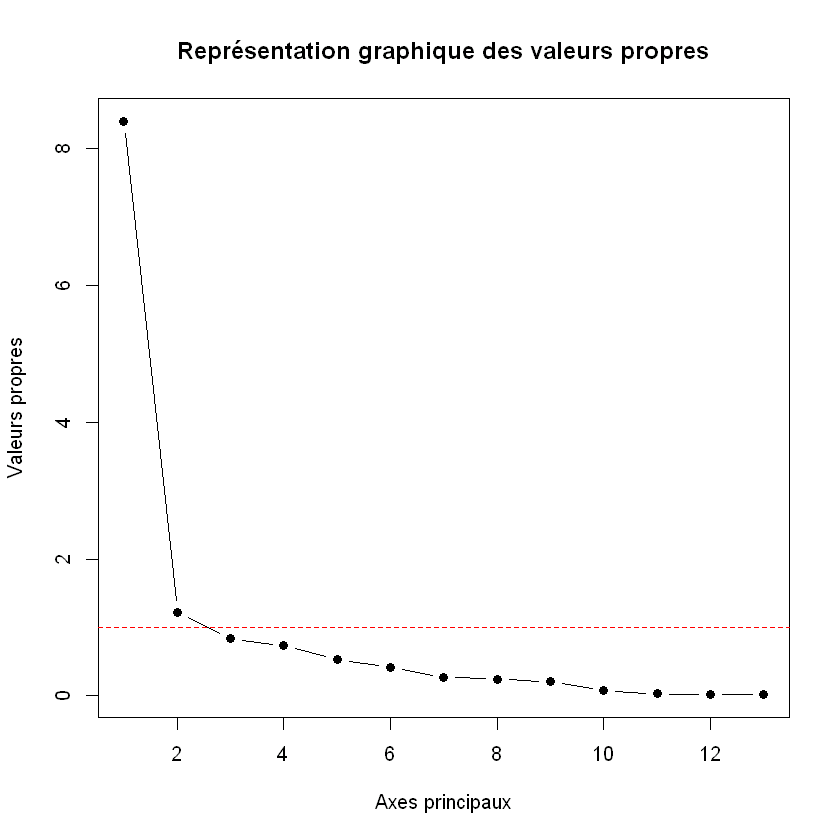

In [64]:
v <- res.pca$eig[, 1]

plot(1:length(vp), vp, type = "b", pch = 19,
     xlab = "Axes principaux",
     ylab = "Valeurs propres",
     main = "Représentation graphique des valeurs propres")
abline(h = 1, col = "red", lty = 2)

png("./graphs_&_tables/valeurs_propres.png", width = 800, height = 600)
